In [181]:
#import requests
from astropy.table import Table
from astropy.io import ascii
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#import requests
from astropy.io import fits
from regions import RectangleSkyRegion, CircleSkyRegion,RegionMeta
from regions import Regions
from regions import PixCoord

from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization import simple_norm
from spectral_cube import SpectralCube
# Access astronomical databases
from pyvo import registry  # version >=1.6
from astroquery.simbad import Simbad
from astroquery.vizier import Vizier
from astroquery.xmatch import XMatch

# Moc and HEALPix tools
from mocpy import MOC

# Open Table

In [3]:
# the catalogue name in VizieR
CATALOGUE_2022 = "J/ApJS/261/13"
#CATALOGUE_2017 = "2017NatAs...1..709O "

# each resource in the VO has an identifier, called ivoid. For vizier catalogs,
# the VO ids can be constructed like this:
catalogue_ivoid = f"ivo://CDS.VizieR/{CATALOGUE_2022}"
# the actual query to the registry
voresource = registry.search(ivoid=catalogue_ivoid)[0]
voresource.describe(verbose=False)
tables = voresource.get_tables()
# We can also extract the tables names for later use
tables_names = list(tables.keys())
tables_names

High-velocity dispersion compact clouds in the CMZ
Short Name: J/ApJS/261/13
IVOA Identifier: ivo://cds.vizier/j/apjs/261/13
Access modes: conesearch, tap#aux, web
- tap#aux: https://tapvizier.cds.unistra.fr/TAPVizieR/tap
- webpage: https://vizier.cds.unistra.fr/viz-bin/VizieR-2?-source=J/ApJS/261/13
- conesearch: https://vizier.cds.unistra.fr/viz-
 bin/conesearch/J/ApJS/261/13/hvdcc?, description: Cone search capability for
 table J/ApJS/261/13/hvdcc (Catalog of high-velocity dispersion compact clouds
 (HVDCCs) and physical parameters (Tables 4 and 5))

This study developed an automated identification procedure for compact clouds
with broad velocity widths in the spectral-line data cubes of highly crowded
regions. The procedure was applied to the CO J=3-2 line data, obtained using
the James Clerk Maxwell Telescope, to identify 184 high-velocity dispersion
compact clouds (HVDCCs), which are a category of peculiar molecular clouds
found in the central molecular zone of our Galaxy. A lis

['J/ApJS/261/13/hvdcc']

In [4]:
# get the first table of the catalogue
first_table_name = tables_names[0]

# execute a synchronous ADQL query
tap_service = voresource.get_service("tap")
tap_records = tap_service.search(
    f'select ALL * from "{first_table_name}"',
)
tap_records

oka2022_tab =tap_records.table

In [7]:
coords = SkyCoord(oka2022_tab['GLON'], oka2022_tab['GLAT'], frame='galactic', unit='deg')
Vlsr = oka2022_tab['Vlsr']
delta_v = oka2022_tab['Sigma']

In [154]:
Drive_path = '/Users/danilipman/Google Drive/Shared drives/ACES/Paper Sprints/Inflow_EVFs/DATA/Identification/TILES_TABLES/'
CS_cubes_path = '/Users/danilipman/Documents/Research/UConn/ACES_EVF/CS21/'
local_path = '/Users/danilipman/Documents/Research/UConn/ACES_EVF/'
reanalysis_path = '/Users/danilipman/Google Drive/Shared drives/ACES/Paper Sprints/Inflow_EVFs/PHASE_VI/REANALYSIS/'

#EVF_tab = Table.read(Drive_path + 'HVCC_resampled_subcube_regions.ecsv')
EVF_tab = Table.read(reanalysis_path+'paper_tables/physical_properties_paper_tab_v4.tex')
EVF_tab.remove_row(0)
EVF_tab.sort('ID Number')
#EVF_ext_tab = Table.read(Drive_path + 'HVCC_resampled_again.ecsv')
EVF_tab_ext = Table.read(reanalysis_path+'paper_tables/full_table.ecsv')
EVF_tab_ext.sort('ID Number')
props_tab = Table.read(reanalysis_path + 'paper_tables/physical_properties_paper_tab.tex')

In [157]:
regions = Regions.read(Drive_path+'HVCC_resampled_regions.reg', format='ds9')



In [158]:
EVF_v_cent  = EVF_ext_tab['V_LSR']*u.km/u.s
EVF_v_width = (EVF_ext_tab['max_v'] - EVF_ext_tab['min_v'])
FWHM = [float(x) for x in np.array(props_tab['Fitted FWHM'][1:].value)]*u.km/u.s

# Open ACES Data

In [16]:
whole_pv_CS = fits.open('/Users/danilipman/Documents/Research/UConn/ACES_EVF/CS21_CubeMosaic_PV_max.fits')
max_CS = fits.open('/Users/danilipman/Documents/Research/UConn/ACES_EVF/CS21_CubeMosaic_max.fits')

/opt/anaconda3/envs/python3_13/lib/python3.13/site-packages/regions/shapes/rectangle.py:205: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Rectangle(xy=xy, width=width, height=height,


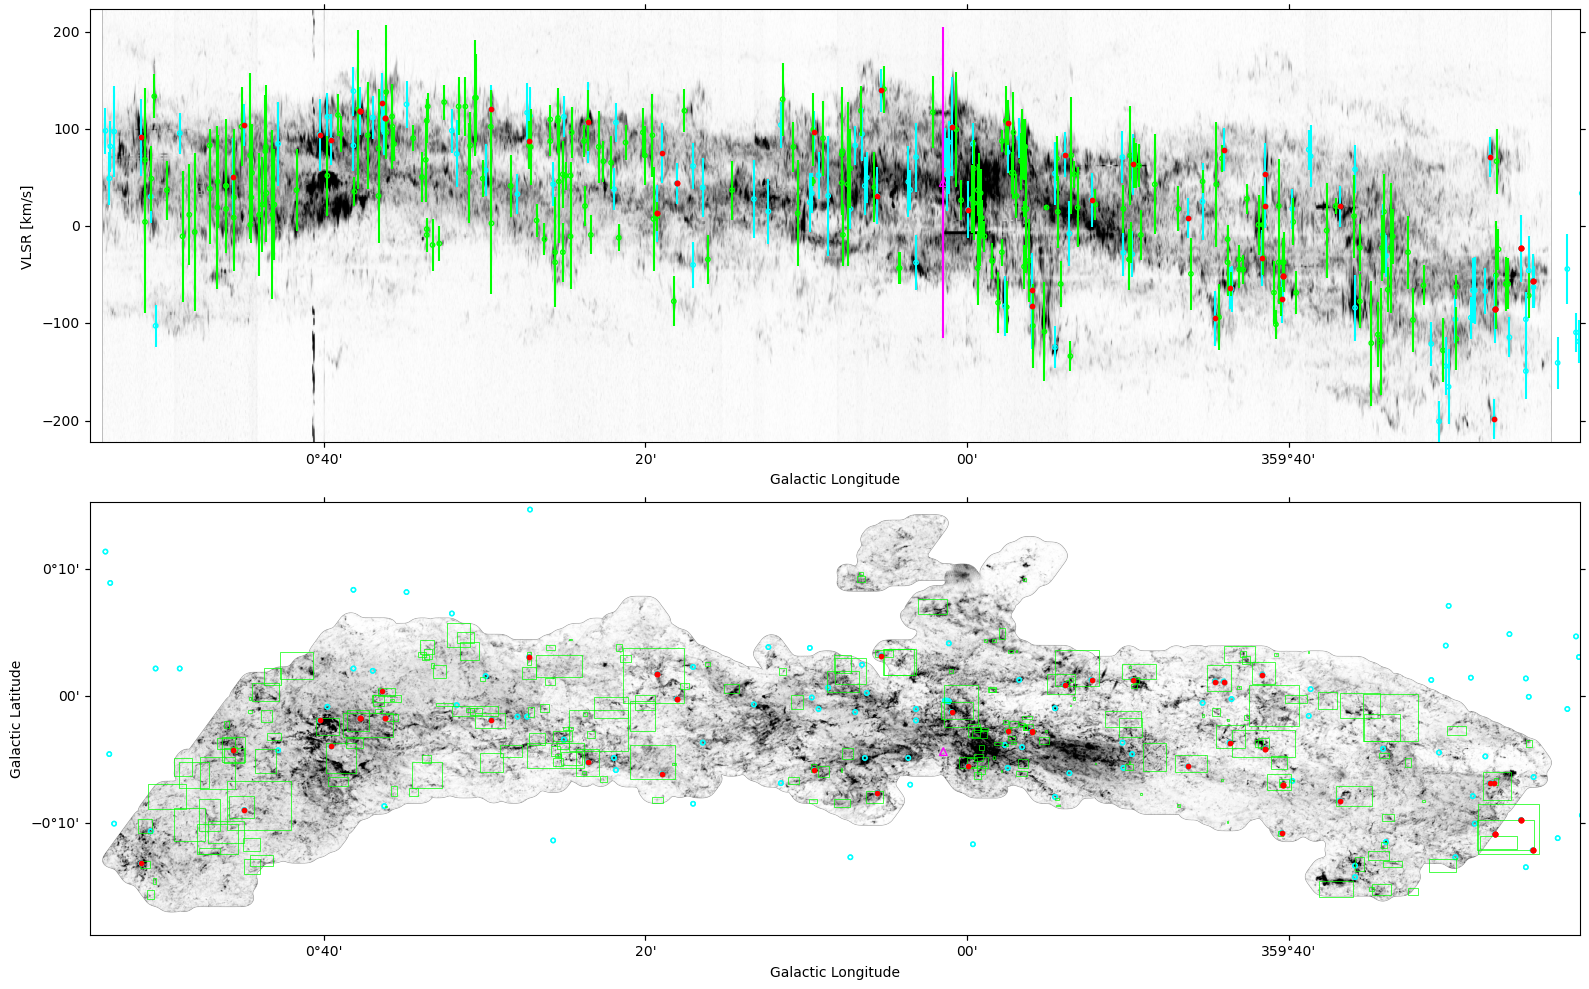

In [38]:
fig = plt.figure(figsize=(16, 10))

### Position-Velocity
ax1 = plt.subplot(211, projection=WCS(whole_pv_CS[0].header))
norm = simple_norm(whole_pv_CS[0].data, stretch='linear', min_percent=1, max_percent=99)
ax1.imshow(whole_pv_CS[0].data, cmap='Grays', aspect='auto', norm=norm)

xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax1.scatter(coords.l, Vlsr.to(u.m/u.s), transform=ax1.get_transform('world'), edgecolor='cyan', facecolor='none', s=10, marker='o')
ax1.scatter(coords.l-360*u.deg, Vlsr.to(u.m/u.s), transform=ax1.get_transform('world'), edgecolor='cyan', facecolor='none', s=10, marker='o')
ax1.errorbar(coords.l, Vlsr.to(u.m/u.s), yerr=delta_v.to(u.m/u.s), fmt='none', color='cyan', transform=ax1.get_transform('world'))
ax1.errorbar(coords.l-360*u.deg, Vlsr.to(u.m/u.s), yerr=delta_v.to(u.m/u.s), fmt='none', color='cyan', transform=ax1.get_transform('world'))

ax1.scatter(EVF_tab['l'], EVF_v_cent.to(u.m/u.s), transform=ax1.get_transform('world'), edgecolor='lime', facecolor='none', s=10, marker='o')
ax1.errorbar(EVF_tab['l'], EVF_v_cent.to(u.m/u.s), yerr=FWHM.to(u.m/u.s), fmt='none', color='lime', transform=ax1.get_transform('world'))

ax1.scatter(0.02467, 45000*(u.m/u.s), transform=ax1.get_transform('world'), edgecolor='magenta', facecolor='none', s=30, marker='^')
ax1.errorbar(0.02467, 45000*(u.m/u.s), yerr=160000*(u.m/u.s), fmt='none', color='magenta', transform=ax1.get_transform('world'))



ax1.set_xlim(xlim)
ax1.set_ylim(ylim)

ax11 = ax1.coords[1]
ax11.set_format_unit(u.km/u.s)
ax11.set_axislabel('VLSR [km/s]')
ax1.set_xlabel('Galactic Longitude')


### Spatial
ax2 = plt.subplot(212, projection=WCS(max_CS[0].header))
norm = simple_norm(max_CS[0].data, stretch='linear', min_percent=1, max_percent=99)
ax2.imshow(max_CS[0].data, cmap='Grays', aspect='auto', norm=norm)

for reg in regions:
    reg_pix = reg.to_pixel(WCS(max_CS[0].header))
    reg_pix.plot(ax=ax2, color='lime',linewidth=0.5,zorder=10)



xlim = ax2.get_xlim()
ylim = ax2.get_ylim()

ax2.scatter(coords.l, coords.b, transform=ax2.get_transform('world'), edgecolor='cyan', facecolor='none', s=10, marker='o')


ax2.scatter(coords.l, coords.b, transform=ax2.get_transform('world'), edgecolor='cyan', facecolor='none', s=10, marker='o')
ax2.scatter(0.02467, -0.0727, transform=ax2.get_transform('world'), edgecolor='magenta', facecolor='none', s=30, marker='^')

#ax2.scatter(EVF_tab['l'], EVF_tab['b'], transform=ax2.get_transform('world'), edgecolor='lime', facecolor='none', s=10, marker='o')

reg_pix_list = [reg.to_pixel(WCS(max_CS[0].header)) for reg in regions]

for i in range(len(reg_pix_list)):
    if reg_pix_list[i].contains(oka_pix).any() == True:
        CS_vlsr = EVF_v_cent[i]
        CS_v_max, CS_v_min = EVF_tab['max_v'][i], EVF_tab['min_v'][i]
        oka_ind = np.where(reg_pix_list[i].contains(oka_pix) == True)[0]
        oka_vlsr = Vlsr[oka_ind]

        for j in oka_vlsr:
            if (j<CS_v_max) & (j>CS_v_min):
                ax2.scatter(coords.l[oka_ind], coords.b[oka_ind], transform=ax2.get_transform('world'), edgecolor='red', facecolor='red', s=10, marker='o',zorder=10)

                ax1.scatter(coords.l[oka_ind], Vlsr[oka_ind].to(u.m/u.s), transform=ax1.get_transform('world'), edgecolor='red', facecolor='red', s=10, marker='o',zorder=10)
                ax1.scatter(coords.l[oka_ind]-360*u.deg, Vlsr[oka_ind].to(u.m/u.s), transform=ax1.get_transform('world'), edgecolor='red', facecolor='red', s=10, marker='o',zorder=10)

#ax2.errorbar(coords.l, coords.b, xerr=delta_l, yerr=delta_b, fmt='none', color='cyan', transform=ax2.get_transform('world'))

ax2.set_xlim(xlim)
ax2.set_ylim(ylim)

ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')

plt.tight_layout()

In [159]:
reg_pix = [reg.to_pixel(WCS(max_CS[0].header)) for reg in regions]


In [160]:


oka_pix = PixCoord.from_sky(coords, WCS(max_CS[0].header))

len(oka_pix)

184

In [15]:
matched = 0

for i in range(len(reg_pix)):
    if reg_pix[i].contains(oka_pix).any() == True:
        CS_vlsr = EVF_v_cent[i]
        CS_v_max, CS_v_min = EVF_tab['max_v'][i], EVF_tab['min_v'][i]
        oka_ind = np.where(reg_pix[i].contains(oka_pix) == True)[0]
        oka_vlsr = Vlsr[oka_ind]

        for j in oka_vlsr:
            if (j<CS_v_max) & (j>CS_v_min):
                matched+=1
        

print(matched)


39


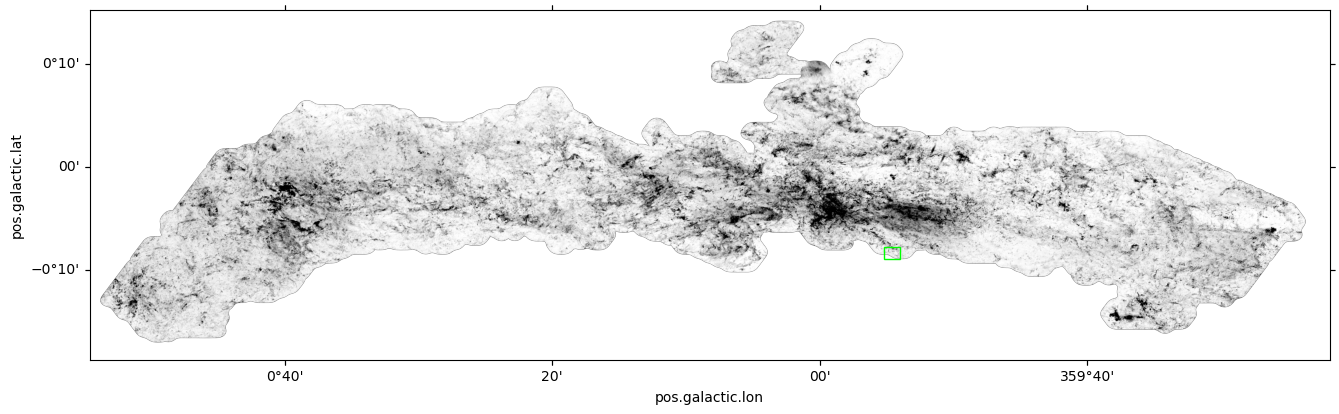

In [21]:
fig = plt.figure(figsize=(16, 10))
norm = simple_norm(max_CS[0].data, stretch='linear', min_percent=1, max_percent=99)

ax1 = plt.subplot(212, projection=WCS(max_CS[0].header))
ax1.imshow(max_CS[0].data, cmap='Grays', aspect='auto', norm=norm)

reg =RectangleSkyRegion(center=SkyCoord(-0.09*u.deg, -0.14*u.deg, frame='galactic'), width=0.02*u.deg, height=0.02*u.deg)
reg.to_pixel(WCS(max_CS[0].header)).plot(ax=ax1, edgecolor='lime', facecolor='lime')

In [19]:
reg

<RectangleSkyRegion(center=<SkyCoord (Galactic): (l, b) in deg
    (359.91, -0.14)>, width=0.02 deg, height=0.02 deg, angle=0.0 deg)>

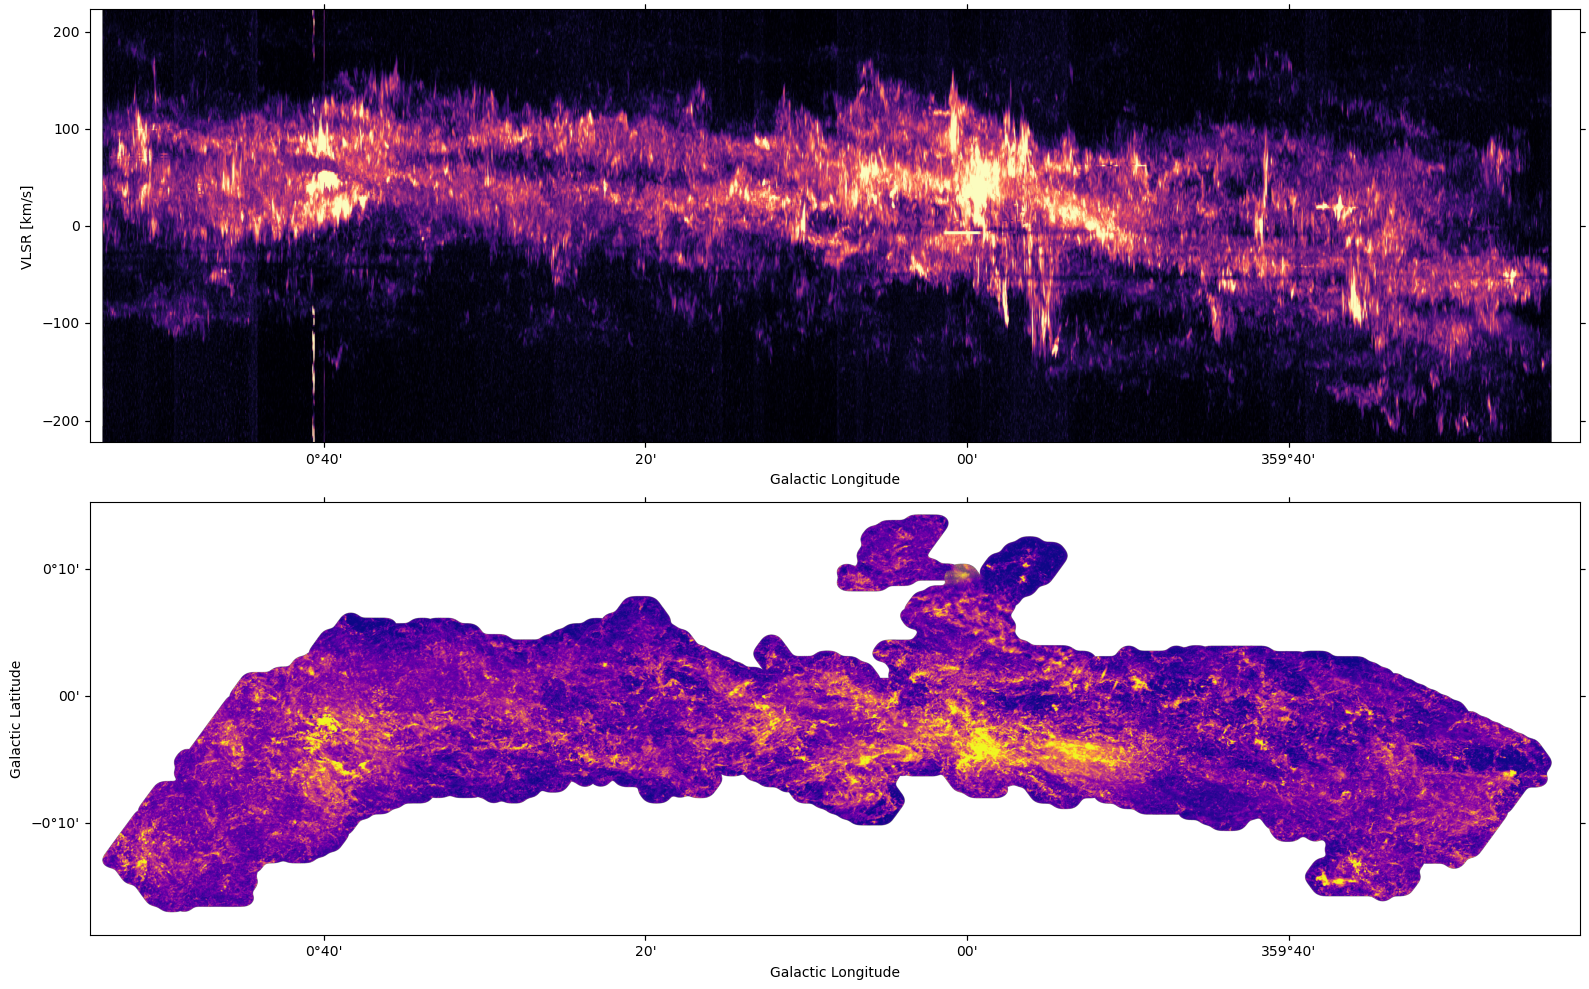

In [12]:
fig = plt.figure(figsize=(16, 10))

### Position-Velocity
ax1 = plt.subplot(211, projection=WCS(whole_pv_CS[0].header))
norm = simple_norm(whole_pv_CS[0].data, stretch='linear', min_percent=5, max_percent=99)
ax1.imshow(whole_pv_CS[0].data, cmap='magma', aspect='auto', norm=norm)

xlim = ax1.get_xlim()
ylim = ax1.get_ylim()


ax1.set_xlim(xlim)
ax1.set_ylim(ylim)

ax11 = ax1.coords[1]
ax11.set_format_unit(u.km/u.s)
ax11.set_axislabel('VLSR [km/s]')
ax1.set_xlabel('Galactic Longitude')


### Spatial
ax2 = plt.subplot(212, projection=WCS(max_CS[0].header))
norm = simple_norm(max_CS[0].data, stretch='linear', min_percent=1, max_percent=99)
ax2.imshow(max_CS[0].data, cmap='plasma', aspect='auto', norm=norm)

xlim = ax2.get_xlim()
ylim = ax2.get_ylim()

#ax2.scatter(EVF_tab['l'], EVF_tab['b'], transform=ax2.get_transform('world'), edgecolor='lime', facecolor='none', s=10, marker='o')


ax2.set_xlim(xlim)
ax2.set_ylim(ylim)

ax2.set_xlabel('Galactic Longitude')
ax2.set_ylabel('Galactic Latitude')

plt.tight_layout()

# Matching with individual sources 

In [161]:
source_coords = "17h45m37.37s -29d00m32.73s" 
source_coords_sky = SkyCoord(source_coords, frame='icrs')
source_gal = source_coords_sky.galactic
print(source_gal)

#convert to pixel
source_gal_pix = PixCoord.from_sky(source_gal, WCS(max_CS[0].header))
print(source_gal_pix)

source_size = 10 #arcsec
source_vmin, source_vmax = -200,-50 #km/s in NeII emission



<SkyCoord (Galactic): (l, b) in deg
    (359.93809325, -0.03852778)>
PixCoord(x=6992.145502601241, y=1969.1981961206197)


In [212]:
EVF_tab_ext[174]

CS Name,ID Number,l,b,deltal,deltab,V_LSR,deltaV,Verticality,Size,Median Intensity,Spectrum FWHM,min_v,max_v,Classification Comments,dendro_match
str15,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str55,float64
CS-0.064_-0.04,174,-0.064,-0.04,0.017221998324885135,0.013749941868529202,-35.6278368,60.864221199999996,1191.273,2.0648550481014736,0.129,nan,-48.988275599999994,11.8759456,nan,nan


In [210]:
regions[174]

<RectangleSkyRegion(center=<SkyCoord (Galactic): (l, b) in deg
    (359.936, -0.04)>, width=0.00916655 deg, height=0.00805551 deg, angle=0.0 deg)>

In [234]:
#Match with Lipman ACES HVCC catalog 
matched_ACES = Table()
matched_reg_ACES = []
for i in range(len(reg_pix)):
    if reg_pix[i].contains(source_gal_pix).any() == True:
        CS_vlsr = EVF_tab['V_LSR'][i]
        CS_v_max, CS_v_min = EVF_tab_ext['max_v'][i]+2, EVF_tab_ext['min_v'][i]-2
        source_ind = i
        source_vlsr = source_vmax
        print(EVF_tab[i])
        if (source_vlsr<CS_v_max) & (source_vlsr>CS_v_min):
            #matched_ACES.add_row(EVF_tab[i])
            matched_reg_ACES.append(regions[i])
            print('velocity match!! ^^')
        else:
            print('not a velocity match')
        



  HVCC Name    ID Number   l      b   V_LSR deltaV Verticality Size Median Intensity Fitted FWHM Peaks PV Classification Detection Method Previous ID Previous Reference
-------------- --------- ------ ----- ----- ------ ----------- ---- ---------------- ----------- ----- ----------------- ---------------- ----------- ------------------
CS -0.064-0.04       174 -0.064 -0.04 -35.6   60.9      3534.1 4.53            0.071        27.6     5                 S                d          --                 --
velocity match!! ^^


In [204]:
#take Oka 2022 table and make circular regions based on the sizes


matched_Oka2022 = Table()
matched_reg_oka2022 = []

for i in range(len(oka2022_tab)):
    center_sky = SkyCoord(oka2022_tab['GLON'][i], oka2022_tab['GLAT'][i], unit='deg', frame='galactic')
    rect_sky = RectangleSkyRegion(
    center=center_sky,
    width =np.rad2deg(oka2022_tab['Size'][i]/8200)*u.deg,
    height=np.rad2deg(oka2022_tab['Size'][i]/8200)*u.deg,
    )
    oka_vlsr = oka2022_tab['Vlsr'][i]
    oka_vmin, oka_vmax = oka_vlsr - oka2022_tab['Sigma'][i], oka_vlsr + oka2022_tab['Sigma'][i] 

    oka_pix_reg = rect_sky.to_pixel(WCS(max_CS[0].header)) 

    if oka_pix_reg.contains(source_gal_pix).any() == True:
        if (source_vlsr<oka_vmax) & (source_vlsr>oka_vmin):
            rect_sky.meta['label'] = oka2022_tab['recno']
            print(oka2022_tab[i])
            print('velocity match!^^')
            matched_reg_oka2022.append(rect_sky)
        

recno Seq   GLON   GLAT   Vlsr  Morph1 Morph2 pID Ref Size Sigma          LCO             MCO          MVT        Ekin    Texp    Pkin  RCO  _RA_icrs _DE_icrs
            deg    deg   km / s                        pc  km / s 100K.km.s**-1.pc**2 100 solMass 100000 solMass 1e+41J 10000 yr 1e+29W        deg      deg   
----- --- ------- ------ ------ ------ ------ --- --- ---- ------ ------------------- ----------- -------------- ------ -------- ------ ---- -------- --------
   76  76 359.933 -0.047  -82.1 simple        CND     5.33   43.8                24.8        83.2          206.8  368.0     11.9  178.7 1.93  266.411  -29.018
velocity match!^^
recno Seq   GLON   GLAT   Vlsr  Morph1 Morph2 pID Ref Size Sigma          LCO             MCO          MVT        Ekin    Texp    Pkin  RCO  _RA_icrs _DE_icrs
            deg    deg   km / s                        pc  km / s 100K.km.s**-1.pc**2 100 solMass 100000 solMass 1e+41J 10000 yr 1e+29W        deg      deg   
----- --- ------- ------ ---

In [202]:
0.62/8.2

0.07560975609756099

In [193]:
matched_reg_oka2022

[<RectangleSkyRegion(center=<SkyCoord (Galactic): (l, b) in deg
     (359.933, -0.047)>, width=0.65 deg, height=0.65 deg, angle=0.0 deg)>,
 <RectangleSkyRegion(center=<SkyCoord (Galactic): (l, b) in deg
     (359.933, -0.046)>, width=0.31341463414634146 deg, height=0.31341463414634146 deg, angle=0.0 deg)>,
 <RectangleSkyRegion(center=<SkyCoord (Galactic): (l, b) in deg
     (0.053, -0.032)>, width=0.2890243902439025 deg, height=0.2890243902439025 deg, angle=0.0 deg)>]

In [115]:
source_gal


<SkyCoord (Galactic): (l, b) in deg
    (359.93809325, -0.03852778)>

In [113]:
matched_reg_oka2022

[<RectangleSkyRegion(center=<SkyCoord (Galactic): (l, b) in deg
     (359.933, -0.047)>, width=0.65 deg, height=0.65 deg, angle=0.0 deg)>,
 <RectangleSkyRegion(center=<SkyCoord (Galactic): (l, b) in deg
     (359.933, -0.046)>, width=0.31341463414634146 deg, height=0.31341463414634146 deg, angle=0.0 deg)>,
 <RectangleSkyRegion(center=<SkyCoord (Galactic): (l, b) in deg
     (0.053, -0.032)>, width=0.2890243902439025 deg, height=0.2890243902439025 deg, angle=0.0 deg)>]

In [194]:
#Oka 2012 regions

url = 'Oka2012_apjs432318t1_ascii.txt'
oka2012_tbl = ascii.read(url, format='csv', delimiter='\t', data_start=4, header_start=2)

matched_Oka2012 = Table()
matched_reg_oka2012 = []

for i in range(len(oka2012_tbl)):
    center_sky = SkyCoord(oka2012_tbl['l'][i], oka2012_tbl['b'][i], unit='deg', frame='galactic')
    rect_sky = RectangleSkyRegion(
    center=center_sky,
    width=oka2012_tbl['Deltal'][i] * u.deg,
    height=oka2012_tbl['Deltab'][i] * u.deg,
    )
    oka_vlsr = oka2012_tbl['V_LSR'][i]
    oka_vmin, oka_vmax = oka_vlsr - oka2012_tbl['DeltaV'][i]/2, oka_vlsr + oka2012_tbl['DeltaV'][i]/2 

    oka_pix_reg = rect_sky.to_pixel(WCS(max_CS[0].header)) 

    if oka_pix_reg.contains(source_gal_pix).any() == True:
        print(oka2012_tbl[i])
        if (source_vlsr<oka_vmax) & (source_vlsr>oka_vmin):
            rect_sky.meta['label'] = oka2012_tbl['Number']
            print('velocity match!^^')
            matched_reg_oka2012.append(rect_sky)
            #matched_Oka2012.add_row(oka2012_tbl[i])
        else:
            print('not a velocity match')
        


Number   l     b   V_LSR Deltal Deltab DeltaV Comments
------ ----- ----- ----- ------ ------ ------ --------
    64 -0.09 -0.04    17   0.06   0.04      2    Sgr A
not a velocity match
Number   l     b   V_LSR Deltal Deltab DeltaV                          Comments                        
------ ----- ----- ----- ------ ------ ------ ---------------------------------------------------------
    67 -0.06 -0.04   -77   0.15   0.16     68 Includes HVCC, CO -0.02-0.02 associated with Sgr A region
velocity match!^^
Number   l     b   V_LSR Deltal Deltab DeltaV                          Comments                         
------ ----- ----- ----- ------ ------ ------ ----------------------------------------------------------
    68 -0.06 -0.05    62   0.15   0.12    120 Includes HVCC, CO -0.04-0.08, associated with Sgr A region
not a velocity match


In [206]:
oka2012_tbl[0]

Number,l,b,V_LSR,Deltal,Deltab,DeltaV,Comments
int64,float64,float64,int64,float64,float64,int64,str72
1,-1.4,-0.11,-139,0.04,0.03,28,"HVCC, CO -1.41-0.08"


In [235]:
matched_regs = []

for i in matched_reg_oka2022:
    matched_regs.append(i)
for i in matched_reg_oka2012:
    matched_regs.append(i)
for i in matched_reg_ACES:
    matched_regs.append(i)

matched_regs = Regions(matched_regs)
matched_regs.write('../ACES_data_cutouts/matched_regions.reg', format='ds9', overwrite=True)


In [232]:
matched_reg_ACES

[<RectanglePixelRegion(center=PixCoord(x=7007.217118084192, y=1958.5980791323475), width=65.99962141441884, height=58.00007748826604, angle=-3.882192345372459e-09 deg)>]